# Tópico 11 – Simulação [<img src="https://raw.githubusercontent.com/urielmoreirasilva/ICX532/main/aulas/T%C3%B3pico%2011%20%E2%80%93%20Simula%C3%A7%C3%A3o/images/colag_logo.svg" style="float: right; vertical-align: middle; width: 42px; height: 42px;">](https://colab.research.google.com/github/urielmoreirasilva/ICX532/blob/main/aulas/T%C3%B3pico%2011%20%E2%80%93%20Simula%C3%A7%C3%A3o/T%C3%B3pico%2011%20%E2%80%93%20Simula%C3%A7%C3%A3o.ipynb) [<img src="https://raw.githubusercontent.com/urielmoreirasilva/ICX532/main/aulas/T%C3%B3pico%2011%20%E2%80%93%20Simula%C3%A7%C3%A3o/images/github_logo.svg" style="float: right; margin-right: 12px; vertical-align: middle; width: 36px; height: 36px;">](https://github.com/urielmoreirasilva/ICX532/blob/main/aulas/T%C3%B3pico%2011%20%E2%80%93%20Simula%C3%A7%C3%A3o/T%C3%B3pico%2011%20%E2%80%93%20Simula%C3%A7%C3%A3o.ipynb)

A simulação de dados é essencial na Estatística e em Ciência de Dados. Vamos aprender a combinar o que aprendemos sobre iteração e sobre arrays para realizar simulações e aproximar probabilidades!

### Resultados Esperados

1. Introduzir método `np.random` para simulação.
1. Aprender sobre como utilizar simulação para aproximar probabilidades.
1. Discutir sobre o uso das simulações como uma alternativa às soluções exatas para problemas complexos.

### Referências
- [CIT, Capítulo 9](https://inferentialthinking.com/)

Material adaptado do [DSC10 (UCSD)](https://dsc10.com/) por [Flavio Figueiredo (DCC-UFMG)](https://flaviovdf.io/fcd/) e [Uriel Silva (DEST-UFMG)](https://urielmoreirasilva.github.io)

In [1]:
## Imports: Matplotlib, Numpy e Pandas.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
plt.style.use('ggplot')

## Simulação

### Ideias básicas

- Suponha que queiramos responder a seguinte pergunta: "Qual é a probabilidade de obtermos 60 ou mais caras no lançamento de 100 moedas justas?" 🤔

- Embora com certeza _seja possível_ calcular essa probabilidade "manualmente", isto é, utilizando Matemática e Probabilidade, podemos também aproximá-la utilizando um computador:
  
1. Descubra como fazer o experimento correspondente (ou seja, jogar 100 moedas justas).
1. Execute o experimento várias vezes.
1. Encontre a proporção de experimentos em que o número de caras foi igual a 60 ou mais.

- Nesse curso, esse será nosso principal uso para técnicas de **simulação**.
- Isto, é, utilizaremos simulação para aproximar a solução _exata_ do problema no qual estamos interessados.
- Embora a maior parte dos problemas que trabalharemos nesse curso _admitam soluções analíticas_, técnicas de simulação são facilmente generalizáveis para os casos onde uma solução analítica seja muito complicada algebricamente, numericamente instável, ou muitas vezes **nem exista**.

- Apesar do poder das técnicas de simulação ser evidente quando aplicadas para resolver problemas complexos, devemos sempre lembrar que a simulação nos dá sempre uma solução **aproximada**.
    - Na maior parte das situações, podemos escolher o quão _boa_ essa aproximação será (em geral ao custo de um esforço computacional maior).
- De qualquer maneira, é sempre uma boa ideia realizarmos uma **análise de sensibilidade** para tentar detectar se nossas aproximações sofrem de algum **viés** (ou **erro sistemático**), muitas vezes decorrentes do comportamento relacionado aos parâmetros dos diferentes métodos de simulação que podemos utilizar na prática.

### Simulando um experimento aleatório

- Para simular um experimento aleatório, precisamos de uma função adequada para gerar _números aleatórios_ no computador.
- Esses números então serão utilizados para representar os resultados de um experimento aleatório (como por exemplo lançar uma moeda, lançar um dado, etc.).

- Uma função muito útil nesse contexto é `np.random.choice(options)`.
    - A entrada dessa função, `options`, é uma lista ou array com todos os possíveis resultados do experimento desejado.
    - A saída dessa função é um elemento selecionado aleatoriamente em `options`.
    - Como padrão, todos os elementos de `options` têm a mesma probabilidade de serem escolhidos, isto é, `np.random.choice` amostra probabilidades **uniformes**.

In [2]:
## Simulando o lançamento de uma moeda (justa)
## Nota: execute essa célula mais de uma vez para ver algo interessante!
np.random.choice(['Heads', 'Tails'])

np.str_('Tails')

In [3]:
## Simulando o lançamento de uma dado (de 6 lados)
## Nota: execute essa célula mais de uma vez para ver algo interessante!
np.random.choice(np.arange(1, 7))

np.int64(6)

### Simulando múltiplos experimentos aleatórios

- Para simularmos `n` experimentos aleatórios, basta invocar `np.random.choice(options, n)`.
- A saída correspondente será um array de `n` elementos selecionados aleatoriamente de `options`.

In [4]:
## Simulando o lançamento de 10 moedas (justas)
# Nota: execute essa célula mais de uma vez para ver algo interessante!
np.random.choice(['Heads', 'Tails'], 10)

array(['Heads', 'Heads', 'Tails', 'Tails', 'Heads', 'Tails', 'Heads',
       'Tails', 'Tails', 'Tails'], dtype='<U5')

### Com reposição ou sem reposição? 🤔

- Como padrão, `np.random.choice` seleciona elementos de `options` **com** reposição.
- Isso significa que, após uma opção ser selecionada, essa opção estará disponível para ser selecionada novamente!

- Por exemplo, se ao retirarmos uma bola de gude de um saco, anotarmos alguma característica de interesse e a colocarmos de volta, estaremos selecionando _com_ reposição.
- Por outro lado, se ao retirarmos a bola de gude do saco não a colocarmos de volta, estaremos selecionando _sem_ reposição.

- Para selecionar **sem** reposição, basta invocar `np.random.choice` com a opção `replace = False`.

In [5]:
## Nesse exemplo, cada elemento de `colleges` é selecionado apenas uma vez.
colleges = ['Revelle', 'John Muir', 'Thurgood Marshall', 
            'Earl Warren', 'Eleanor Roosevelt', 'Sixth', 'Seventh']

np.random.choice(colleges, 3, replace = False)

array(['John Muir', 'Earl Warren', 'Eleanor Roosevelt'], dtype='<U17')

## Simulando probabilidades

### Exemplo #1. Probabilidade de obter 60 ou mais caras no lançamento de 100 moedas

Voltando à nossa pergunta original, vamos detalhar abaixo cada um dos passos da estratégia de simulação que delineamos anteriormente.

#### Passo 1: Descobrir como fazer o experimento 

- Nesse exemplo, podemos utilizar `np.random.choice` para simular o lançamento de 100 moedas:

In [6]:
coins = np.random.choice(['Heads', 'Tails'], 100)
coins

array(['Tails', 'Tails', 'Tails', 'Heads', 'Heads', 'Tails', 'Tails',
       'Heads', 'Heads', 'Tails', 'Tails', 'Tails', 'Heads', 'Tails',
       'Heads', 'Tails', 'Heads', 'Heads', 'Tails', 'Tails', 'Tails',
       'Tails', 'Heads', 'Heads', 'Heads', 'Tails', 'Heads', 'Tails',
       'Heads', 'Tails', 'Tails', 'Tails', 'Heads', 'Heads', 'Heads',
       'Heads', 'Heads', 'Tails', 'Heads', 'Tails', 'Tails', 'Heads',
       'Heads', 'Tails', 'Tails', 'Tails', 'Heads', 'Heads', 'Heads',
       'Tails', 'Heads', 'Heads', 'Heads', 'Heads', 'Heads', 'Heads',
       'Tails', 'Tails', 'Heads', 'Tails', 'Tails', 'Tails', 'Heads',
       'Tails', 'Tails', 'Heads', 'Tails', 'Tails', 'Heads', 'Heads',
       'Tails', 'Tails', 'Tails', 'Heads', 'Tails', 'Tails', 'Heads',
       'Tails', 'Heads', 'Tails', 'Heads', 'Tails', 'Tails', 'Heads',
       'Tails', 'Tails', 'Tails', 'Heads', 'Heads', 'Heads', 'Tails',
       'Heads', 'Tails', 'Tails', 'Heads', 'Heads', 'Heads', 'Heads',
       'Heads', 'Hea

e depois, podemos contar o número de caras utilizando a função `np.count_nonzero`:

In [7]:
np.count_nonzero(coins == 'Heads')

np.int64(50)

- Em essência, a função `np.count_nonzero(array)` retorna o número de entradas em `array` que são `True`.

In [8]:
coins == 'Heads'

array([False, False, False,  True,  True, False, False,  True,  True,
       False, False, False,  True, False,  True, False,  True,  True,
       False, False, False, False,  True,  True,  True, False,  True,
       False,  True, False, False, False,  True,  True,  True,  True,
        True, False,  True, False, False,  True,  True, False, False,
       False,  True,  True,  True, False,  True,  True,  True,  True,
        True,  True, False, False,  True, False, False, False,  True,
       False, False,  True, False, False,  True,  True, False, False,
       False,  True, False, False,  True, False,  True, False,  True,
       False, False,  True, False, False, False,  True,  True,  True,
       False,  True, False, False,  True,  True,  True,  True,  True,
        True])

Lembrando que as booleanas `True` e `False` são codificadas no Python como sendo iguas a 1 e 0, respectivamente, podemos alternativamente contar o número de caras através de:

In [9]:
(coins == 'Heads').sum()

np.int64(50)

Isso também motiva o nome da função `count_nonzero`: como `False == 0`, a função conta os elementos diferentes de 0, isto é, aqueles que são iguais a `True`. 

#### Interlúdio: Definindo uma função para simular o experimento aleatório

- Para facilitar a repetição do experimento (e aumentar a legibilidade do código), podemos definir uma função para executar o Passo 1 acima:

In [10]:
def coin_experiment():
    '''Simulates 100 (fair) coin tosses and returns the number of Heads.'''
    coins = np.random.choice(['Heads', 'Tails'], 100)
    return np.count_nonzero(coins == 'Heads')

In [11]:
coin_experiment?

Signature: coin_experiment()
Docstring: Simulates 100 (fair) coin tosses and returns the number of Heads.
File:      /tmp/ipykernel_17718/3756918760.py
Type:      function

In [12]:
coin_experiment()

np.int64(57)

#### Passo 2: Repetir o experimento várias vezes

- Como vimos no Tópico 08, podemos repetir o mesmo código muitas vezes **utilizando um loop `for`!**
- Cada vez que simularmos o experimento, precisaremos armazenar os resultados em um array.
    - Faremos isso aqui através da função `np.append`.

Para ilustrar o uso do `np.append`, começamos com um array vazio:

In [13]:
head_counts = np.array([])
head_counts

array([], dtype=float64)

Fazemos então um append ao array existente:

In [14]:
head_counts = np.append(head_counts, 15)
head_counts

array([15.])

e mais um:

In [15]:
head_counts = np.append(head_counts, 25)
head_counts

array([15., 25.])

... e assim por diante.

Nosso `for` para repetir o experimento aleatório várias vezes então fica assim:

In [16]:
## Número de repetições
repetitions = 10000

## Começamos com um array vazio para armazenar os resultados
head_counts = np.array([])

## Loop for
for i in np.arange(repetitions):
    ## Para cada repetição, execute o experimento e adicione o resultado a `head_counts`
    head_count = coin_experiment()
    head_counts = np.append(head_counts, head_count)

In [17]:
len(head_counts)

10000

In [18]:
head_counts

array([54., 50., 52., ..., 53., 45., 57.], shape=(10000,))

#### Passo 3: Encontrar a proporção de experimentos em que o número de caras foi igual a 60 ou mais

- Calculamos agora então a proporção $\hat{p}$ dos experimentos em que o número de caras foi igual a 60 ou mais.
- Essa medida de _frequência_ nos fornece a **probabilidade estimada** do nosso evento, isto é, "obter 60 ou mais caras em 100 lançamentos de uma moeda".

O _número de experimentos_ em que o número de caras observado foi igual a 60 ou mais é:

In [19]:
at_least_60 = np.count_nonzero(head_counts >= 60)
at_least_60

np.int64(304)

... e a _proporção correspondente_ $\hat{p}$, isto é, sobre todos as repetições do experimento aleatório, é igual a

In [20]:
p_hat = at_least_60 / repetitions
p_hat

np.float64(0.0304)

Lembrando que a soma das booleanas de uma array nos dá sempre o número de elementos que são iguais a `True`, a proporção $\hat{p}$ é igual a _média das booleanas correspondentes_ (em Probabilidade, denominamos essas booleanas como **indicadoras da ocorrência de um evento**):

In [21]:
head_counts >= 60

array([False, False, False, ..., False, False, False], shape=(10000,))

In [22]:
np.mean(head_counts >= 60)

np.float64(0.0304)

#### Visualizando a distribuição dos experimentos aleatórios simulados

O histograma abaixo contém a distribuição do número de caras em cada um dos experimentos:

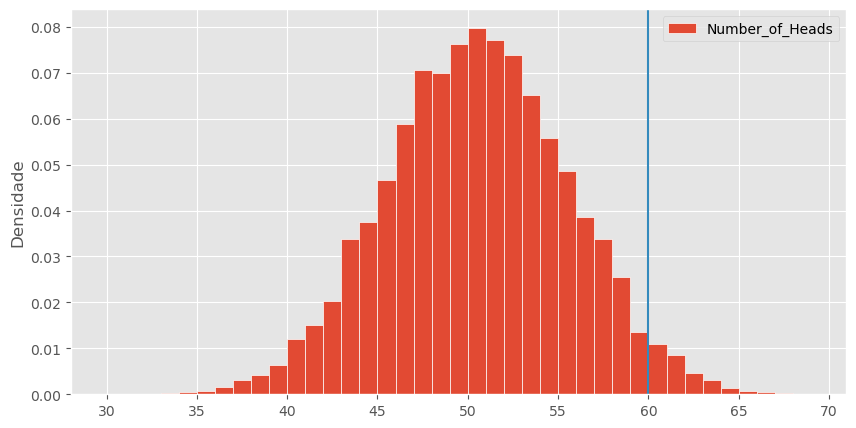

In [23]:
pd.DataFrame().assign(
    Number_of_Heads=head_counts
).plot(kind = 'hist', bins = np.arange(30, 70), density = True, ec = 'w', figsize = (10, 5));
plt.axvline(60, color = 'C1');
plt.ylabel('Densidade');

- Lembrando que o histograma acima é um _histograma de densidade_, as barras representam _frequências relativas_, e logo _estimativas da probabilidade_ de cada classe.
- Em outras palavras, o histograma descreve a "distribuição das probabilidades de cada um dos valores de caras observados em 100 lançamentos de uma moeda", aproximada por simulação!
    - Introduziremos com mais precisão o conceito de "distribuição de probabilidade" no Tópico 12.

#### Verificando a qualidade da simulação

Nossa probabilidade de "60 caras ou mais em 100 lançamentos de uma moeda", estimada através de simulação, é igual a:

In [24]:
np.mean(head_counts >= 60)

np.float64(0.0304)

Como mencionado anteriormente, conseguimos calcular também essa probabilidade de maneira _exata_/_analítica_, utilizando a [distribuição Binomial](https://en.wikipedia.org/wiki/Binomial_distribution).

Sem adentrar em mais detalhes técnicos, a probabilidade de "60 caras ou mais em 100 lançamentos de uma moeda" calculada através da distribuição Binomial é: 

In [25]:
## A distribuição Binomial é importada do SciPy, e toma parâmetros `n` e `p`
from scipy.stats import binom
n = 100
p = 0.5
grid = np.arange(60, n + 1, 1)
binom.pmf(grid, n, p).sum()

np.float64(0.028443966820490354)

A simulação produziu um resultado bem próximo ao real! 👍

- Finalmente, podemos ainda sobrepor a distribuição do número de caras em 100 lançamentos calculada através da simulação (histograma, em vermelho) contra os valores exatos correspondentes (gráfico de barras, em azul), calculados através da distribuição Binomial:

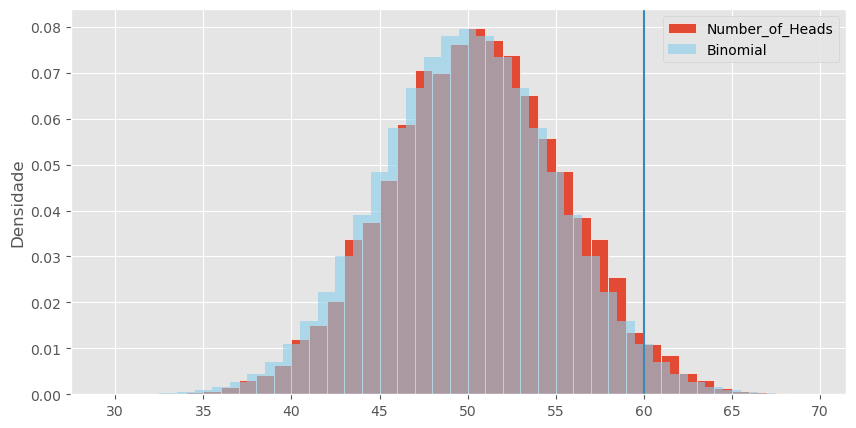

In [26]:
## Histograma: distribuição simulada
pd.DataFrame().assign(
    Number_of_Heads=head_counts
).plot(kind = 'hist', bins = np.arange(30, 70), density = True, ec = 'w', figsize = (10, 5));
plt.axvline(60, color = 'C1');
plt.ylabel('Densidade');

## Gráfico de barras: distribuição exata
n = 100
p = 0.5
x = np.arange(30, 70)
y = binom.pmf(x, n, p)
dd = pd.DataFrame()
dd = dd.assign(grid = x, probs = y)
plt.bar(x, y, linewidth = 2, color = 'skyblue', alpha = 0.60, width = 1, label = 'Binomial')
plt.legend();

### Exemplo #2. [O paradoxo dos aniversários](https://en.wikipedia.org/wiki/Birthday_problem)

- Como outro exemplo de uma aplicação das técnicas de simulação para estimar probabilidades, considere o problema que é conhecido popularmente como **"Paradoxo dos Aniversários"**.

- O paradoxo dos aniversários diz que, em uma sala com $n$ pessoas, precisamos de apenas $n = 23$ para que a probabilidade de que duas ou mais pessoas tenham o mesmo aniversário seja maior que $1/2 = 50\%$!
- Esse fato é surpreendente (e logo considerado um "paradoxo") porque a intuição simples nos diria que, como temos $N = 365$ dias em um ano, precisaríamos de $n \simeq 365/2$ pessoas para que a probabilidade de interesse fosse maior ou igual a $1/2$.

- E como será que podemos calcular essa probabilidade via simulação? 🤔

#### Passo 1: Descobrir como fazer o experimento 

- Nesse caso, o experimento aleatório consiste em sortear números de 1 a 365 (os aniversários), e o nosso evento de interesse é o número de pessoas cujos aniversários caem no mesmo dia, em uma sala de $n$ pessoas.

<u> Nota</u>: aqui ignoraremos anos bissextos, e é possível que exista mais de um aniversário que se repita (por exemplo, se 2 pessoas fazem aniversário no dia 05/01 e mais 3 fazem aniversário no dia 08/03, nossa contagem de pessoas será igual a 5).

Como exemplo inicial, vamos tomar $n = 60$, e simular os aniversários:

In [27]:
n = 60
birthdays = np.random.choice(np.arange(1, 365 + 1, 1), n)
birthdays

array([105,  43, 280, 121,  48, 213, 305,   7,  95, 216, 164, 252,  43,
        93, 103, 127, 251,  39,  58,  60, 266,  22,   5, 120,  80,  23,
       194, 342,  16,  41, 105, 362, 356,  76,  34, 277,  25,  35,  67,
       210, 165, 224,   2, 212,  25,  45, 212, 221, 288,  10,   8, 110,
       269,   1, 154,  87, 214, 270, 352, 273])

Agora, para contar o número de valores que _não se repetem_, vamos utilizar `len` e `np.unique`:

In [28]:
np.unique(birthdays)

array([  1,   2,   5,   7,   8,  10,  16,  22,  23,  25,  34,  35,  39,
        41,  43,  45,  48,  58,  60,  67,  76,  80,  87,  93,  95, 103,
       105, 110, 120, 121, 127, 154, 164, 165, 194, 210, 212, 213, 214,
       216, 221, 224, 251, 252, 266, 269, 270, 273, 277, 280, 288, 305,
       342, 352, 356, 362])

In [29]:
len(np.unique(birthdays))

56

E, finalmente, para contar o número de valores que _se repetem_, podemos tomar:

In [30]:
## Note que sempre temos n == len(birthdays) >= len(np.unique(birthdays).
n - len(np.unique(birthdays))

4

Como fizemos anteriormente, vamos agora então encapsular esse comportamento em uma função:

In [31]:
def birthday_experiment(n):
    '''Simulates n birthdays and returns the number of matches.'''
    birthdays = np.random.choice(np.arange(1, 365 + 1, 1), n)
    return n - len(np.unique(birthdays))

In [32]:
birthday_experiment(60)

8

#### Passo 2: Repetir o experimento várias vezes

- Repetimos agora nosso experimento $M = 10000$ vezes, tomando $n = 23$:

In [33]:
## Número de repetições
repetitions = 10000

## Número de pessoas
n = 23

## Começamos com um array vazio para armazenar os resultados
birthday_matches = np.array([])

## Loop for
for i in np.arange(repetitions):
    ## Para cada repetição, execute o experimento e adicione o resultado a `bithday_matches`
    birthdays = birthday_experiment(n)
    birthday_matches = np.append(birthday_matches, birthdays)

#### Passo 3: Encontrar a proporção de experimentos em que 2 ou mais pessoas tenham o mesmo aniversário

Finalmente, para encontrar o número de experimentos em que o evento de interesse ocorre, fazemos:

In [34]:
at_least_a_birthday_match = np.count_nonzero(birthday_matches >= 1)
at_least_a_birthday_match

np.int64(5041)

e, finalmente, a proporção correspondente é igual a:

In [35]:
p_hat = at_least_a_birthday_match / repetitions
p_hat

np.float64(0.5041)

O paradoxo parece realmente ser verdadeiro!

#### Visualizando a distribuição dos experimentos aleatórios simulados

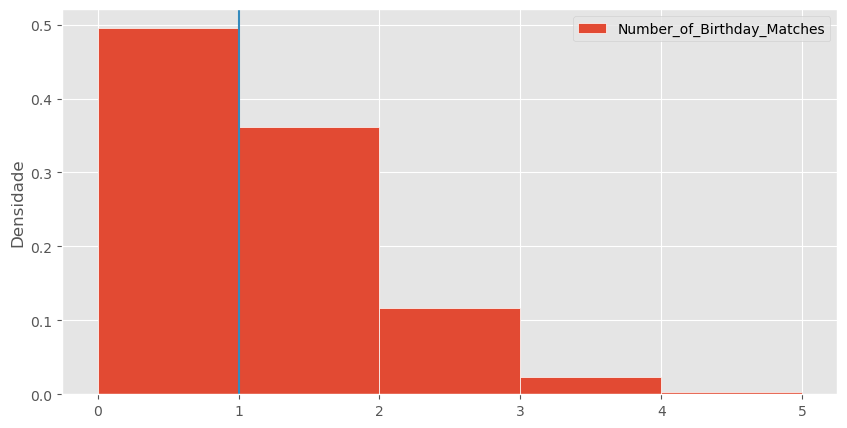

In [36]:
## Histograma: distribuição simulada
## Escolhendo o número de classes do histograma
m = int(birthday_matches.max())
bins = np.arange(m + 1)

## Elaborando o histograma
pd.DataFrame().assign(
    Number_of_Birthday_Matches = birthday_matches
).plot(kind = 'hist', bins = bins, density = True, ec = 'w', figsize = (10, 5));
plt.axvline(1, color = 'C1');
plt.ylabel('Densidade');

#### Verificando a qualidade da simulação

- É possível calcular analiticamente a probabilidade de que, em uma sala de $n$ pessoas, 2 ou mais pessoas tenham o mesmo aniversário.
- Mais especificamente, defina o evento $A_n = \text{``2 ou mais pessoas tenham o mesmo aniversário''}$, para $n = 1, \ldots, 365$.
- Com um pouco (na verdade muito!) de análise combinatória, é possível mostrar que

\begin{equation*}
    P(A_n) = 1 - \frac{P_{365, n}}{365^n} = 1 - \frac{n! \cdot \binom{365}{n}}{365^n}
\end{equation*}

Para calcular fatoriais e combinações, primeiramente importamos o módulo `math`.

In [37]:
import math as math
print(math.factorial(3))
print(math.comb(6, 2))

6
15


Aqui, calculamos $P(A_n)$ para $1 \leq n \leq 365$:

In [38]:
N = 365
probs = []
for n in np.arange(1, N + 1, 1):
    i_n = int(n)
    prob_an = 1 - (math.factorial(i_n) * math.comb(N, i_n)) / (N ** i_n)
    probs = np.append(probs, prob_an)

Finalmente, printamos um DataFrame com `n` e `P(A_n)`:

In [39]:
## Customizando como printar objetos do NumPy e do pandas
np.set_printoptions(threshold = 20, precision = 2, suppress = True)
pd.set_option("display.max_rows", 40)
pd.set_option("display.max_columns", 8)
pd.set_option("display.precision", 2)

## Printando o DataFrame
prob = pd.DataFrame()
prob = prob.assign(n = np.arange(1, N + 1, 1), p_n = probs)
prob

,n,p_n
0,1,0.00e+00
1,2,2.74e-03
2,3,8.20e-03
3,4,1.64e-02
4,5,2.71e-02
...,...,...
360,361,1.00e+00
361,362,1.00e+00
362,363,1.00e+00
363,364,1.00e+00


In [40]:
# Consultando a linha correspondente a n = 23
prob[prob.get('n') == 23]

,n,p_n
22,23,0.51


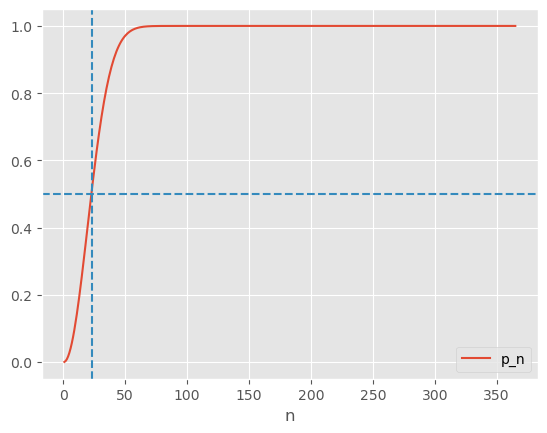

In [41]:
## Podemos também fazer um gráfico de linhas com os diversos valores de `n` e `P(A_n)`
prob.plot(x = 'n', y = 'p_n', kind = 'line')
plt.axvline(23, linestyle = '--', color = 'C1');
plt.axhline(0.50, linestyle = '--', color = 'C1');

- Finalmente, a probabilidade calculada através de simulação foi igual a:

In [42]:
p_hat

np.float64(0.5041)

e a calculada de maneira exata foi de:

In [43]:
1 - (math.factorial(23) * math.comb(365, 23)) / (365 ** 23)

0.5072972343239854

Mais uma vez concluímos que ambas são bem próximas! 👍

## Resumo

#### Podemos utilizar simulação para estimar probabilidades

- Calcular probabilidades é importante, mas pode ser difícil!
- A simulação nos permite encontrar probabilidades por meio de computadores em vez de utilizar matemática.
- Alguns cenários do mundo real são muito complicados, e técnicas de simulação podem ser a única solução em muitos destes casos.

#### Como realizar uma simulação

Para estimar a probabilidade de um evento por meio de simulação:
1. Crie uma função que execute o experimento uma vez.
1. Execute essa função muitas e muitas vezes através de um loop `for`, e salve os resultados em um array com `np.append`.
1. Calcule a proporção de vezes que o evento ocorre utilizando `np.count_nonzero`.